# Master fitting file

Change only `CONFIG_FILE` near the top, then run the notebook.

Available model names:

- `{model choice}_{gate template concentration}_{fuel tempalte concentration}`

Saved results are written to the `results/` folder by default.

## 1. Setup and model definition

Run this whole section every time.  
Contents: 
0) Imports
1) Load configuration files
2) Load Excel experimental data
3) Build datasets
4) Visual check for data transient vs steady state
5) 

These cells define the experimental data, parameter defaults, model equations,
simulation helper, bounds, and residual function used by both fitting and loading workflows.


In [17]:
# ============================================================
# 0) IMPORTS
# ============================================================
import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import scipy.integrate as spi
import xlrd
from tqdm import tqdm

from scipy.optimize import least_squares

from model_registry import get_model


In [18]:
# ============================================================
# 1) LOAD CONFIG / USER CHOICES
#
# Purpose:
#   - Load all user choices from one config file
#   - Choose which model to run
#   - Choose which experimental conditions to fit
#   - Automatically identify the held-out condition
#   - Load parameter values, bounds, data settings, and save settings
# ============================================================

# Choose which config file to load
CONFIG_FILE = "configs/fit_exps1234_model1_active_gate_fuel.json"

# Open the JSON config file
with open(CONFIG_FILE, "r") as f:

    # Read the JSON file into a Python dictionary
    config = json.load(f)

# This name is used to identify the run, save files, and label outputs
RUN_NAME = config["run_name"]

# Read model name from config
MODEL_NAME = config["model_name"]

# Load the matching model module from model_registry.py
model = get_model(MODEL_NAME)

# These are the experimental conditions used for parameter fitting
FIT_CONDITIONS = config["fit_conditions"]

# This is the full set of possible experimental conditions
# It is used to determine which condition was not included in the fit
ALL_CONDITIONS = config["all_conditions"]

# Find conditions in ALL_CONDITIONS that are not in FIT_CONDITIONS
held_out = [c for c in ALL_CONDITIONS if c not in FIT_CONDITIONS]

# Make sure there is exactly one held-out condition
# This notebook currently assumes a 5-condition setup:
#   4 fitted conditions + 1 held-out condition
assert len(held_out) == 1, (
    "Expected exactly one held-out condition. "
    f"Got {len(held_out)}: {held_out}"
)

# Store the single held-out condition
HELD_OUT_CONDITION = held_out[0]

# These are the parameters that least_squares will optimize
FIT_PARAMS = config["fit_params"]

# Convert config values into the ALL_PARAM_INFO format used by the notebook
ALL_PARAM_INFO = {
    p: {"central": float(v)}
    for p, v in config["all_param_central"].items()
}

# Number of random initial guesses used for multi-start fitting
N_STARTS = int(config["n_starts"])

# Random seed for reproducible initial guesses
RANDOM_SEED = int(config["random_seed"])

# Bounds are stored in normal parameter units in the config
# They are converted to floats here
CUSTOM_PARAM_BOUNDS = {
    p: (float(bounds[0]), float(bounds[1]))
    for p, bounds in config["custom_param_bounds"].items()
}

# Path to the Excel file containing the experimental data
# If not specified in config, use the default path
EXCEL_FILE = config.get("excel_file", "../in_vitro_ctRSD_modeling_data.xls")

# Name of the Excel sheet to load
# If not specified in config, use the default sheet name
EXCEL_SHEET = config.get("excel_sheet", "Fig. 4H (SciAdv) fuel")

# These define where each experimental trajectory is cut
# Rows before row_end are used for fitting
# Rows from row_end onward are used to estimate the plateau
row_end_map = {
    int(k): int(v)
    for k, v in config["row_end_map"].items()
}

# MODE controls whether to run fitting or load previous results
MODE = config.get("mode", "fit")

# Make sure MODE is valid
assert MODE in ["fit", "load"], "mode must be either 'fit' or 'load'"

# Read results directory from config, or use "results" by default
RESULTS_DIR = Path(config.get("results_dir", "results"))

# Create results directory if it does not already exist
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Use the config filename if provided
# Otherwise automatically use RUN_NAME_results.npz
FIT_RESULTS_FILE = str(RESULTS_DIR / config.get(
    "fit_results_file",
    f"{RUN_NAME}_results.npz"
))

# Print run summary
print("============================================================")
print(f"Loaded config: {CONFIG_FILE}")
print(f"Run name: {RUN_NAME}")
print(f"Model: {MODEL_NAME}")
print(f"Mode: {MODE}")
print(f"Fit conditions: {FIT_CONDITIONS}")
print(f"Held-out condition: {HELD_OUT_CONDITION}")
print(f"Fit parameters: {FIT_PARAMS}")
print(f"Results file: {FIT_RESULTS_FILE}")
print("============================================================")

Loaded config: configs/fit_exps1234_model1_active_gate_fuel.json
Run name: fit_exps1234_model1_active_gate_fuel
Mode: fit
Fit conditions: ['1p25in_0fuel', '2p5in_0fuel', '0in_25fuel', '1p25in_25fuel']
Held-out condition: 2p5in_25fuel
Fit parameters: ['k_txn', 'ksd', 'kfsd', 'krev', 'kf_rep', 'kRz', 'klkg', 'basal_frac']
Results file: results/fit_exps1234_model1_active_gate_fuel.npz
Run name: fit_exps1234_model1_active_gate_fuel
Model: model1_active_gate_fuel
Fit conditions: ['1p25in_0fuel', '2p5in_0fuel', '0in_25fuel', '1p25in_25fuel']
Held-out condition: 2p5in_25fuel
Fit params: ['k_txn', 'ksd', 'kfsd', 'krev', 'kf_rep', 'kRz', 'klkg', 'basal_frac']


In [19]:
# ============================================================
# 2) LOAD EXCEL AND DEFINE CONDITION MAP
# ============================================================

wb = xlrd.open_workbook(EXCEL_FILE)
ws = wb.sheet_by_name(EXCEL_SHEET)

# DDn[:,0] = 0 nM Input,   0 nM Fuel
# DDn[:,1] = 1.25 nM Input,0 nM Fuel
# DDn[:,2] = 2.5 nM Input, 0 nM Fuel
# DDn[:,3] = 0 nM Input,   25 nM Fuel
# DDn[:,4] = 1.25 nM Input,25 nM Fuel
# DDn[:,5] = 2.5 nM Input, 25 nM Fuel

CONDITIONS = {
    "0in_0fuel":     (0, 0.0, 0.0),
    "1p25in_0fuel":  (1, 1.25, 0.0),
    "2p5in_0fuel":   (2, 2.5, 0.0),
    "0in_25fuel":    (3, 0.0, 25.0),
    "1p25in_25fuel": (4, 1.25, 25.0),
    "2p5in_25fuel":  (5, 2.5, 25.0),
}

print(f"Loaded Excel file: {EXCEL_FILE}")
print(f"Loaded sheet: {EXCEL_SHEET}")
print("Using row_end_map from config:")
print(row_end_map)


Loaded Excel file: ../in_vitro_ctRSD_modeling_data.xls
Loaded sheet: Fig. 4H (SciAdv) fuel
Using row_end_map from config:
{1: 1309, 2: 526, 3: 787, 4: 265, 5: 200}


In [20]:
# # ============================================================
# # 3) BUILD DATASETS
# #    - fit region = rows 3 : row_end
# #    - plateau region = rows row_end : end
# #    - DRL_0 = average plateau value
# # ============================================================

# datasets = []

# for cond in FIT_CONDITIONS:

#     # Read condition info
#     col_idx, IN_conc, Fuel_conc = CONDITIONS[cond]

#     # Read row cutoff for this condition
#     row_end = row_end_map[col_idx]

#     # --------------------------------------------------------
#     # Load fit region
#     # --------------------------------------------------------
#     n_fit_rows = row_end - 3

#     t_fit = np.zeros(n_fit_rows)
#     x_fit_frac = np.zeros(n_fit_rows)

#     for r in range(3, row_end):
#         t_fit[r - 3] = ws.cell_value(r, 0)
#         x_fit_frac[r - 3] = ws.cell_value(r, col_idx + 1)

#     # Convert fraction reacted -> nM reacted
#     x_fit = x_fit_frac * 500.0

#     # --------------------------------------------------------
#     # Load plateau region
#     # --------------------------------------------------------
#     n_plateau_rows = ws.nrows - row_end

#     if n_plateau_rows > 0:
#         t_plateau = np.zeros(n_plateau_rows)
#         x_plateau_frac = np.zeros(n_plateau_rows)

#         for r in range(row_end, ws.nrows):
#             t_plateau[r - row_end] = ws.cell_value(r, 0)
#             x_plateau_frac[r - row_end] = ws.cell_value(r, col_idx + 1)

#         x_plateau = x_plateau_frac * 500.0
#         plateau_avg = np.mean(x_plateau)

#     else:
#         t_plateau = np.array([])
#         x_plateau = np.array([])
#         plateau_avg = x_fit[-1]

#     # --------------------------------------------------------
#     # Set experiment-specific initial reporter pool
#     # ROL(0) = 0
#     # DRL(0) = plateau average
#     # --------------------------------------------------------
#     DRL_0 = plateau_avg

#     datasets.append({
#         "name": f"{IN_conc} nM Input, {Fuel_conc} nM Fuel",
#         "cond_key": cond,
#         "col_idx": col_idx,
#         "row_end": row_end,
#         "IN_conc": IN_conc,
#         "Fuel_conc": Fuel_conc,
#         "t_exp": t_fit,
#         "x_exp": x_fit,
#         "t_plateau": t_plateau,
#         "x_plateau": x_plateau,
#         "plateau_avg": plateau_avg,
#         "DRL_0": DRL_0
#     })

# print("Loaded datasets:")
# for d in datasets:
#     print(
#         f'{d["name"]} | '
#         f'fit pts = {len(d["t_exp"])} | '
#         f'plateau pts = {len(d["x_plateau"])} | '
#         f'plateau_avg = {d["plateau_avg"]:.2f} nM | '
#         f'DRL_0 = {d["DRL_0"]:.2f} nM'
#     )

In [21]:
# ============================================================
# 3) BUILD DATASETS
#    - fit region = rows 3 : row_end
#    - plateau region = rows row_end : end
#    - DRL_0 = average plateau value
# ============================================================

def build_dataset(cond):

    # Read condition info
    col_idx, IN_conc, Fuel_conc = CONDITIONS[cond]

    # Read row cutoff for this condition
    row_end = row_end_map[col_idx]

    # --------------------------------------------------------
    # Load fit region
    # --------------------------------------------------------
    n_fit_rows = row_end - 3

    t_fit = np.zeros(n_fit_rows)
    x_fit_frac = np.zeros(n_fit_rows)

    for r in range(3, row_end):
        t_fit[r - 3] = ws.cell_value(r, 0)
        x_fit_frac[r - 3] = ws.cell_value(r, col_idx + 1)

    # Convert fraction reacted -> nM reacted
    x_fit = x_fit_frac * 500.0

    # --------------------------------------------------------
    # Load plateau region
    # --------------------------------------------------------
    n_plateau_rows = ws.nrows - row_end

    if n_plateau_rows > 0:

        t_plateau = np.zeros(n_plateau_rows)
        x_plateau_frac = np.zeros(n_plateau_rows)

        for r in range(row_end, ws.nrows):
            t_plateau[r - row_end] = ws.cell_value(r, 0)
            x_plateau_frac[r - row_end] = ws.cell_value(r, col_idx + 1)

        x_plateau = x_plateau_frac * 500.0
        plateau_avg = np.mean(x_plateau)

    else:

        t_plateau = np.array([])
        x_plateau = np.array([])
        plateau_avg = x_fit[-1]

    # Reporter pool initial condition
    DRL_0 = plateau_avg

    return {
        "name": f"{IN_conc} nM Input, {Fuel_conc} nM Fuel",
        "cond_key": cond,
        "col_idx": col_idx,
        "row_end": row_end,
        "IN_conc": IN_conc,
        "Fuel_conc": Fuel_conc,
        "t_exp": t_fit,
        "x_exp": x_fit,
        "t_plateau": t_plateau,
        "x_plateau": x_plateau,
        "plateau_avg": plateau_avg,
        "DRL_0": DRL_0
    }


# Build fitted datasets
datasets = [build_dataset(cond) for cond in FIT_CONDITIONS]

# Build held-out dataset
HELD_OUT_DATASET = build_dataset(HELD_OUT_CONDITION)

print("Loaded fitted datasets:")
for d in datasets:
    print(
        f'{d["name"]} | '
        f'fit pts = {len(d["t_exp"])} | '
        f'plateau pts = {len(d["x_plateau"])} | '
        f'plateau_avg = {d["plateau_avg"]:.2f} nM | '
        f'DRL_0 = {d["DRL_0"]:.2f} nM'
    )

print("\nLoaded held-out dataset:")
print(
    f'{HELD_OUT_DATASET["name"]} | '
    f'fit pts = {len(HELD_OUT_DATASET["t_exp"])} | '
    f'plateau pts = {len(HELD_OUT_DATASET["x_plateau"])} | '
    f'plateau_avg = {HELD_OUT_DATASET["plateau_avg"]:.2f} nM | '
    f'DRL_0 = {HELD_OUT_DATASET["DRL_0"]:.2f} nM'
)

Loaded fitted datasets:
1.25 nM Input, 0.0 nM Fuel | fit pts = 1306 | plateau pts = 1201 | plateau_avg = 490.73 nM | DRL_0 = 490.73 nM
2.5 nM Input, 0.0 nM Fuel | fit pts = 523 | plateau pts = 1984 | plateau_avg = 485.83 nM | DRL_0 = 485.83 nM
0.0 nM Input, 25.0 nM Fuel | fit pts = 784 | plateau pts = 1723 | plateau_avg = 491.79 nM | DRL_0 = 491.79 nM
1.25 nM Input, 25.0 nM Fuel | fit pts = 262 | plateau pts = 2245 | plateau_avg = 487.32 nM | DRL_0 = 487.32 nM

Loaded held-out dataset:
2.5 nM Input, 25.0 nM Fuel | fit pts = 197 | plateau pts = 2310 | plateau_avg = 482.73 nM | DRL_0 = 482.73 nM


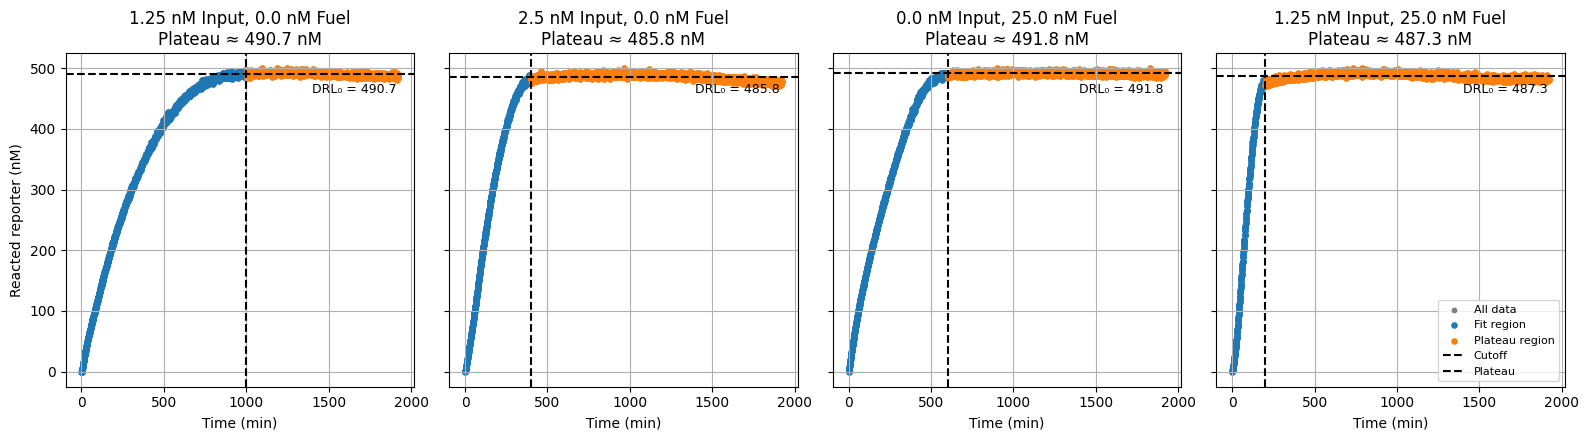

In [22]:
# ============================================================
# 4) VISUAL CHECK: FIT REGION vs PLATEAU REGION
# ============================================================

# Number of datasets (one subplot per condition)
n = len(datasets)

# Create horizontal panel of subplots
fig, axes = plt.subplots(1, n, figsize=(4*n, 4.5), sharey=True)

# Ensure axes is iterable if only one dataset
if n == 1:
    axes = [axes]

# Loop over datasets and plot each one
for ax, d in zip(axes, datasets):

    # --------------------------------------------------------
    # Combine full dataset (fit + plateau) for reference
    # --------------------------------------------------------
    t_full = np.concatenate([d["t_exp"], d["t_plateau"]])
    x_full = np.concatenate([d["x_exp"], d["x_plateau"]])

    # Plot all data in background (gray)
    ax.scatter(
        t_full,
        x_full,
        s=10,
        color='gray',
        label='All data'
    )

    # --------------------------------------------------------
    # Highlight fit region (used in optimization)
    # --------------------------------------------------------
    ax.scatter(
        d["t_exp"],
        d["x_exp"],
        s=14,
        label='Fit region'
    )

    # --------------------------------------------------------
    # Highlight plateau region (used to estimate steady state)
    # --------------------------------------------------------
    if len(d["t_plateau"]) > 0:
        ax.scatter(
            d["t_plateau"],
            d["x_plateau"],
            s=14,
            label='Plateau region'
        )

    # --------------------------------------------------------
    # Draw cutoff line separating fit vs plateau
    # --------------------------------------------------------
    # This corresponds to row_end in Excel
    ax.axvline(
        d["t_exp"][-1],
        linestyle='--',
        linewidth=1.5,
        color='black',
        label='Cutoff'
    )

    # --------------------------------------------------------
    # Draw plateau average (used as DRL_0)
    # --------------------------------------------------------
    ax.axhline(
        d["plateau_avg"],
        linestyle='--',
        linewidth=1.5,
        color='black',
        label='Plateau'
    )

    # --------------------------------------------------------
    # Formatting
    # --------------------------------------------------------
    ax.set_title(
        f'{d["name"]}\nPlateau ≈ {d["plateau_avg"]:.1f} nM'
    )
    ax.set_xlabel('Time (min)')
    ax.grid(True)
    ax.text(0.95, 0.88, f'DRL₀ = {d["DRL_0"]:.1f}', transform=ax.transAxes, fontsize=9, ha='right')

# Shared y-axis label
axes[0].set_ylabel('Reacted reporter (nM)')

# Only show legend once (last panel)
axes[-1].legend(fontsize=8)

plt.tight_layout()
plt.show()

In [24]:
# ============================================================
# 6) MODEL SELECTION
# ============================================================

# The actual ODE equations live in the models/ folder.
# The config file selects which one is used.

print(f"Using model: {MODEL_NAME}")
print(f"State variables: {model.STATE_NAMES}")
print(f"Reacted reporter index: {model.ROL_INDEX}")


Using model: model1_active_gate_fuel
State variables: ['uRSDg', 'RSDg', 'IN', 'OUT', 'DRL', 'ROL', 'I_RSDg', 'F', 'F_RSDg']
Reacted reporter index: 5


In [ ]:
# ============================================================
# 7) SIMULATION HELPER
#
# Purpose:
#   - Simulate the selected model for a given experimental condition
#   - Return reacted reporter (ROL) at experimental timepoints
# ============================================================

RSD_temp = 25.0

def simulate_ROL(t_exp, IN_conc, Fuel_conc, DRL_0, params):

    # Initial conditions are defined by whichever model is selected.
    x0_local = model.initial_conditions(DRL_0)

    # Convert time from minutes to seconds
    t_eval_sec = np.asarray(t_exp, dtype=float) * 60.0
    tspan = (t_eval_sec[0], t_eval_sec[-1])

    # Solve ODE system
    sol = spi.solve_ivp(
        lambda t, x: model.RSD_eqs(t, x, RSD_temp, IN_conc, Fuel_conc, params),
        tspan,
        x0_local,
        t_eval=t_eval_sec,
        method='LSODA',
        rtol=1e-6,
        atol=1e-6
    )

    # Failure handling
    if (not sol.success) or np.any(~np.isfinite(sol.y)):
        return np.full_like(t_exp, 1e9, dtype=float)

    # Return reacted reporter
    return sol.y[model.ROL_INDEX]


In [26]:
# ============================================================
# 8) BUILD CUSTOM BOUNDS AND MULTI-START GUESSES
# ============================================================

# Get central values in log10 space
log10_central = {
    p: np.log10(ALL_PARAM_INFO[p]["central"])   # log10(default value)
    for p in FIT_PARAMS
}

# Build bounds (log10 for fitting, linear for plotting)
FIT_BOUNDS = {}   # linear-scale bounds (for plotting / reference)

lower_bounds = []  # log10 lower bounds (for least_squares)
upper_bounds = []  # log10 upper bounds

for p in FIT_PARAMS:

    if p not in CUSTOM_PARAM_BOUNDS:
        raise ValueError(f"Missing bounds for fitted parameter: {p}")  # safety check

    lb, ub = CUSTOM_PARAM_BOUNDS[p]   # user-defined linear bounds

    if lb <= 0 or ub <= 0:
        raise ValueError(f"Bounds for {p} must be positive (log10 requirement).")

    if lb >= ub:
        raise ValueError(f"Bounds for {p} must satisfy lower < upper.")

    lower_bounds.append(np.log10(lb))   # convert to log10 for optimizer
    upper_bounds.append(np.log10(ub))

    FIT_BOUNDS[p] = (lb, ub)   # keep linear bounds for plotting

lower_bounds = np.array(lower_bounds)   # shape: (n_params,)
upper_bounds = np.array(upper_bounds)

# Baseline guess (log10 space)
baseline_guess = np.array([
    log10_central[p]   # use default parameter values
    for p in FIT_PARAMS
])

# Ensure baseline lies inside chosen bounds
for i, p in enumerate(FIT_PARAMS):

    if not (lower_bounds[i] <= baseline_guess[i] <= upper_bounds[i]):
        raise ValueError(
            f"Baseline value for {p} is outside CUSTOM_PARAM_BOUNDS. "
            f"Baseline = {10**baseline_guess[i]:.3e}, "
            f"Bounds = [{FIT_BOUNDS[p][0]:.3e}, {FIT_BOUNDS[p][1]:.3e}]"
        )

# Generate multi-start guesses
rng = np.random.default_rng(RANDOM_SEED)   # reproducible randomness

guess_list = [baseline_guess]   # first guess = default model

for _ in range(N_STARTS - 1):
    g = rng.uniform(lower_bounds, upper_bounds)   # sample in log10 space
    guess_list.append(g)

print("Fitting parameters:", FIT_PARAMS)
print("Number of starting guesses:", len(guess_list))

print("\nFit bounds used:")
for p in FIT_PARAMS:
    lb, ub = FIT_BOUNDS[p]
    print(f"{p:>10s}: [{lb:.3e}, {ub:.3e}]")

print("\nFirst guess = baseline/default model.")


Fitting parameters: ['k_txn', 'ksd', 'kfsd', 'krev', 'kf_rep', 'kRz', 'klkg', 'basal_frac']
Number of starting guesses: 50

Fit bounds used:
     k_txn: [9.628e-04, 9.628e-02]
       ksd: [9.978e-07, 9.978e-05]
      kfsd: [2.300e-07, 2.300e-05]
      krev: [1.427e-07, 1.427e-05]
    kf_rep: [4.771e-07, 4.771e-05]
       kRz: [4.068e-03, 4.068e-01]
      klkg: [6.990e-06, 6.990e-04]
basal_frac: [2.205e-03, 2.205e+00]

First guess = baseline/default model.


In [27]:
# ============================================================
# 9) FLEXIBLE GLOBAL RESIDUAL FUNCTION
#
# Purpose:
#   - Take a vector of log10 parameters (from optimizer)
#   - Convert to physical parameter values
#   - Simulate model for ALL datasets
#   - Return one concatenated residual vector
#
# Notes:
#   - Only parameters in FIT_PARAMS are varied
#   - All others remain fixed at central values
# ============================================================

def residuals_selected_params(log10_param_array):

    # --------------------------------------------------------
    # 1) Initialize parameter dictionary with default values
    # --------------------------------------------------------
    # This ensures non-fitted parameters remain fixed
    params = {
        p: ALL_PARAM_INFO[p]["central"]
        for p in ALL_PARAM_INFO
    }

    # --------------------------------------------------------
    # 2) Overwrite fitted parameters
    # --------------------------------------------------------
    for i, p in enumerate(FIT_PARAMS):

        # Convert log10 → physical value
        params[p] = 10**log10_param_array[i]

    # --------------------------------------------------------
    # 3) Compute residuals across ALL datasets
    # --------------------------------------------------------
    res_all = []

    for d in datasets:

        # Simulate model
        x_model = simulate_ROL(
            t_exp=d["t_exp"],
            IN_conc=d["IN_conc"],
            Fuel_conc=d["Fuel_conc"],
            DRL_0=d["DRL_0"],   # dataset-specific reporter pool
            params=params
        )

        # ----------------------------------------------------
        # Normalize residuals
        # ----------------------------------------------------

        # Raw residual = model - experiment
        res = x_model - d["x_exp"]

        # Vertical normalisation factor:
        # Prevent one dataset dominating due to signal scale
        scale = np.max(d["x_exp"]) if np.max(d["x_exp"]) > 0 else 1.0

        # Horizontal normalisation factor:
        # Prevent one dataset dominating due to number of points
        points = len(d["x_exp"])

        # Normalize residuals
        res = res / scale / np.sqrt(points)

        # Append
        res_all.append(res)

    # --------------------------------------------------------
    # 4) Return one long residual vector (required by least_squares)
    # --------------------------------------------------------
    return np.concatenate(res_all)

## 2. Fit or load mode

`MODE` is now controlled by the config file.

- Use `"fit"` to run a fresh least-squares optimization and save the result.
- Use `"load"` to skip optimization and continue from a previously saved fit file.


In [28]:
# ============================================================
# MODE CHECK
#
# MODE and FIT_RESULTS_FILE are set in the config cell above.
# Choose "fit" or "load" by editing the config file, not this cell.
# ============================================================

assert MODE in ["fit", "load"], "MODE must be 'fit' or 'load'"

print(f"Running in MODE = {MODE}")
print(f"Fit results file = {FIT_RESULTS_FILE}")


Running in MODE = fit
Fit results file = results/fit_exps1234_model1_active_gate_fuel.npz


## 3. Fitting / loading checkpoint

This is the breakpoint in the notebook.

- In **fit** mode, the next cells will run the optimization and save `best_x` and `best_cost`.
- In **load** mode, the optimization cell is skipped and those values are loaded from disk.

All later analysis cells use the shared variables:
- `FIT_PARAMS`
- `best_x`
- `best_cost`
- `best_fit_params`


In [29]:
# ============================================================
# 10) MULTI-START OPTIMIZATION
# ============================================================

if MODE == "fit":

    print("Using fresh optimization result")

    best_result = None   # store best solution

    # Progress bar over guesses
    pbar = tqdm(guess_list, desc="Fitting multi-starts")

    for g in pbar:

        result = least_squares(
            residuals_selected_params,
            x0=g,
            bounds=(lower_bounds, upper_bounds)
        )

        # Keep best result
        if (best_result is None) or (result.cost < best_result.cost):
            best_result = result
            pbar.set_postfix({"best_cost": f"{best_result.cost:.2e}"})

    # Save outputs
    best_x = best_result.x
    best_cost = best_result.cost

    print(f"\nBest cost found: {best_cost:.3e}")

else:
    print("Skipping optimization because MODE = 'load'")


Using fresh optimization result


Fitting multi-starts: 100%|██████████| 50/50 [02:11<00:00,  2.63s/it, best_cost=3.68e-02]


Best cost found: 3.676e-02


In [30]:
# ============================================================
# 11) SAVE FIT RESULTS
# ============================================================

if MODE == "fit":

    np.savez(
        FIT_RESULTS_FILE,
        param_names=np.array(FIT_PARAMS),
        best_x=best_x,
        best_cost=best_cost
    )

    print(f"Saved fit results to {FIT_RESULTS_FILE}")

else:
    print("Skipping save because MODE = 'load'")


Saved fit results to results/fit_exps1234_model1_active_gate_fuel.npz


### Load saved fit

Run this cell as part of the normal notebook flow.  
It only loads data when `MODE = "load"`.


In [31]:
# ============================================================
# 12) LOAD FIT RESULTS
#
# Purpose:
#   - If MODE == "fit", this reloads the result just saved to disk.
#   - If MODE == "load", this loads a previous result and skips fitting.
# ============================================================

data = np.load(FIT_RESULTS_FILE, allow_pickle=True)

FIT_PARAMS = list(data["param_names"])
best_x = data["best_x"]
best_cost = data["best_cost"]

print(f"Loaded fit results from {FIT_RESULTS_FILE}")

if MODE == "fit":
    print("Using freshly saved optimization result")
else:
    print("Using previously saved optimization result")


Loaded fit results from results/fit_exps1234_model1_active_gate_fuel.npz
Using freshly saved optimization result


## 4. Analysis and plotting

In [32]:
# ============================================================
# 12) EXTRACT BEST-FIT PARAMETERS
# ============================================================

best_fit_params = {
    p: ALL_PARAM_INFO[p]["central"]
    for p in ALL_PARAM_INFO
}

for i, p in enumerate(FIT_PARAMS):
    best_fit_params[p] = 10**best_x[i]

print("============================================================")
print("BEST-FIT PARAMETERS")
print("============================================================")
for p in best_fit_params:
    print(f"{p:>10s} = {best_fit_params[p]:.6e}")
print(f"Cost       = {best_cost:.6e}")
print("============================================================")


BEST-FIT PARAMETERS
     k_txn = 1.699048e-03
       ksd = 9.698621e-05
      kfsd = 2.294804e-05
      krev = 3.357915e-06
    kf_rep = 1.833247e-06
       kRz = 2.969873e-01
basal_frac = 5.714434e-01
      klkg = 1.078526e-05
Cost       = 3.675765e-02


-------------------------------------------------
You can now use the fitted result for diagnostics and figures.


In [33]:
# ============================================================
# 12a) COMPUTE SSE / RMSE FOR EACH DATASET
#
# Metrics:
#   - SSE  (Sum of Squared Errors)
#         = Σ (model - experiment)^2
#         → sensitive to total error magnitude
#
#   - RMSE (Root Mean Squared Error)
#         = sqrt(mean((model - experiment)^2))
#         → error per datapoint (more interpretable scale)
# ============================================================

# Store residuals for each dataset (for global RMSE calculation later)
residuals_list = []

# For each dataset
for d in datasets:

    # Simulate model using best-fit parameters
    x_fit = simulate_ROL(
        t_exp=d["t_exp"],
        IN_conc=d["IN_conc"],
        Fuel_conc=d["Fuel_conc"],
        DRL_0=d["DRL_0"],
        params=best_fit_params
    )

    # Residual = model - experiment
    res = x_fit - d["x_exp"]

    # Store residuals for global RMSE calculation later
    residuals_list.append(res)

    # Compute SSE and RMSE
    sse = np.sum(res**2)
    rmse = np.sqrt(np.mean(res**2))

    # Print results
    print(f'{d["name"]}')
    print(f'  SSE  = {sse:.6e}')
    print(f'  RMSE = {rmse:.6e}')


# ============================================================
# 12b) GLOBAL RMSE (REUSING RESIDUALS)
# ============================================================

# Concatenate all residuals from Cell 12a
res_all = np.concatenate(residuals_list)

global_sse = np.sum(res_all**2)
global_rmse = np.sqrt(np.mean(res_all**2))

print("============================================================")
print("GLOBAL ERROR (FITTED 4 EXPERIMENTS)")
print("============================================================")
print(f"Global SSE  = {global_sse:.6e}")
print(f"Global RMSE = {global_rmse:.6e}")
print("============================================================")

1.25 nM Input, 0.0 nM Fuel
  SSE  = 3.874994e+06
  RMSE = 5.447082e+01
2.5 nM Input, 0.0 nM Fuel
  SSE  = 1.223847e+06
  RMSE = 4.837409e+01
0.0 nM Input, 25.0 nM Fuel
  SSE  = 8.254424e+06
  RMSE = 1.026090e+02
1.25 nM Input, 25.0 nM Fuel
  SSE  = 5.073426e+05
  RMSE = 4.400480e+01
GLOBAL ERROR (FITTED 4 EXPERIMENTS)
Global SSE  = 1.386061e+07
Global RMSE = 6.943401e+01


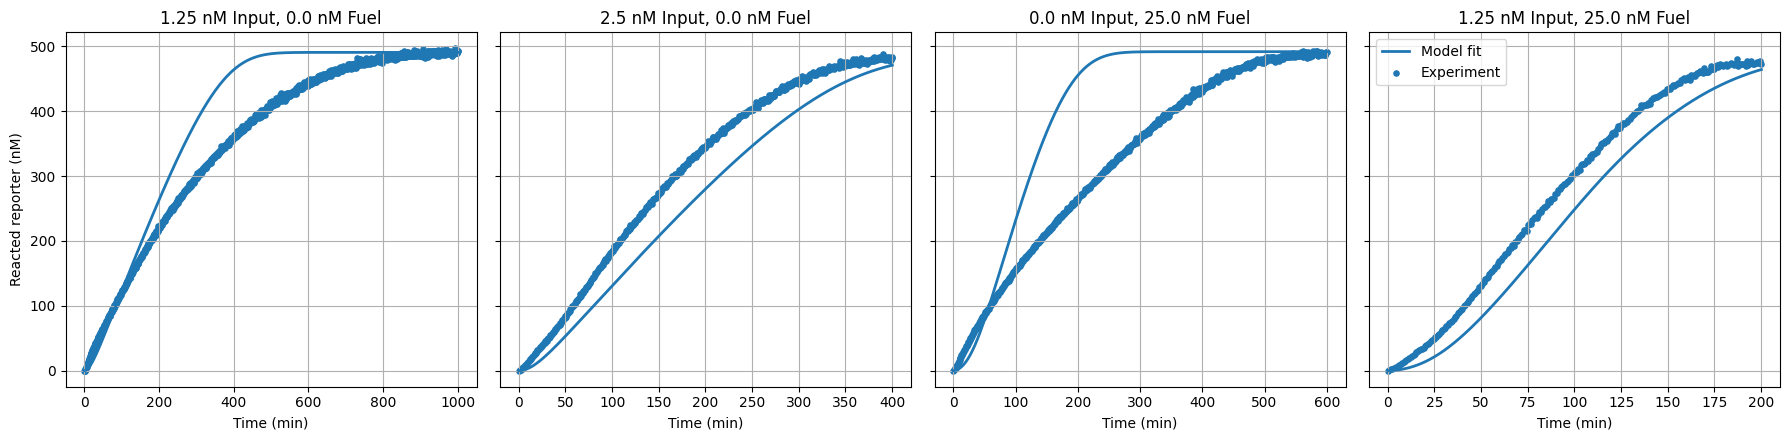

In [34]:
# ============================================================
# 13) PLOT BEST-FIT TIMECOURSES
# ============================================================

# Make one subplot per dataset
n = len(datasets)
fig, axes = plt.subplots(1, n, figsize=(4.5*n, 4.5), sharey=True)

# If only one dataset, axes will not be a list
if n == 1:
    # so make it a list for consistent indexing
    axes = [axes]

# For each experiment were fitting
for ax, d in zip(axes, datasets):

    # Simulate model using best-fit parameters
    x_fit = simulate_ROL(
        t_exp=d["t_exp"],
        IN_conc=d["IN_conc"],
        Fuel_conc=d["Fuel_conc"],
        DRL_0=d["DRL_0"],
        params=best_fit_params
    )

    # Plot model fit and experimental data
    ax.plot(d["t_exp"], x_fit, linewidth=2, label='Model fit')
    ax.scatter(d["t_exp"], d["x_exp"], s=14, label='Experiment')
    ax.set_title(d["name"])
    ax.set_xlabel('Time (min)')
    ax.grid(True)

axes[0].set_ylabel('Reacted reporter (nM)')
axes[-1].legend()

plt.tight_layout()
plt.show()

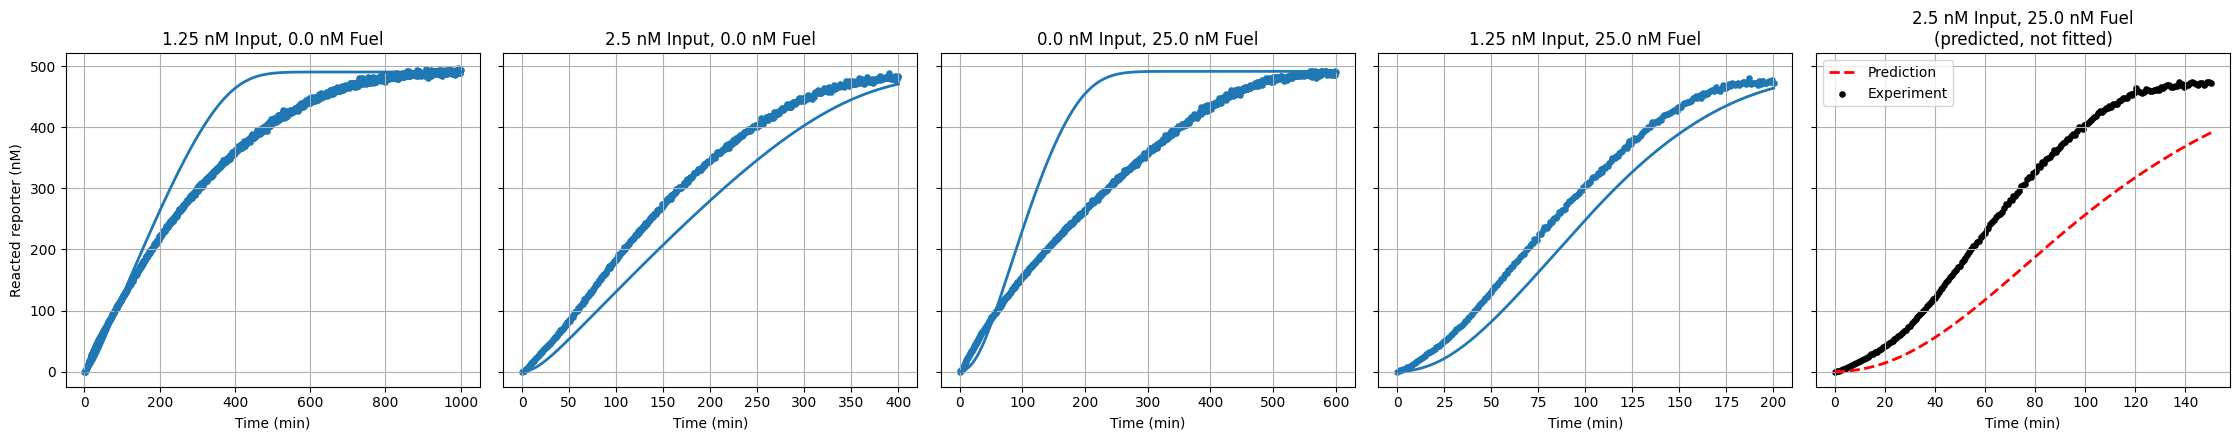

In [35]:
# ============================================================
# 13b) PLOT BEST-FIT TIMECOURSES + HELD-OUT PREDICTION
# ============================================================

# Total plots = fitted datasets + held-out dataset
n = len(datasets) + 1

fig, axes = plt.subplots(1, n, figsize=(4.5*n, 4.5), sharey=True)

if n == 1:
    axes = [axes]

# ------------------------------------------------------------
# 1) Plot fitted datasets
# ------------------------------------------------------------
for ax, d in zip(axes[:-1], datasets):

    x_fit = simulate_ROL(
        t_exp=d["t_exp"],
        IN_conc=d["IN_conc"],
        Fuel_conc=d["Fuel_conc"],
        DRL_0=d["DRL_0"],
        params=best_fit_params
    )

    ax.plot(d["t_exp"], x_fit, linewidth=2, label="Model fit")
    ax.scatter(d["t_exp"], d["x_exp"], s=14, label="Experiment")

    ax.set_title(d["name"])
    ax.set_xlabel("Time (min)")
    ax.grid(True)

# ------------------------------------------------------------
# 2) Plot held-out prediction
# ------------------------------------------------------------
ax = axes[-1]
d = HELD_OUT_DATASET

x_pred = simulate_ROL(
    t_exp=d["t_exp"],
    IN_conc=d["IN_conc"],
    Fuel_conc=d["Fuel_conc"],
    DRL_0=d["DRL_0"],
    params=best_fit_params
)

ax.plot(
    d["t_exp"],
    x_pred,
    linewidth=2,
    linestyle="--",
    color="red",
    label="Prediction"
)

ax.scatter(
    d["t_exp"],
    d["x_exp"],
    s=14,
    color="black",
    label="Experiment"
)

ax.set_title(f'{d["name"]}\n(predicted, not fitted)')
ax.set_xlabel("Time (min)")
ax.grid(True)

# ------------------------------------------------------------
# 3) Formatting
# ------------------------------------------------------------
axes[0].set_ylabel("Reacted reporter (nM)")
axes[-1].legend()

plt.tight_layout()
plt.show()

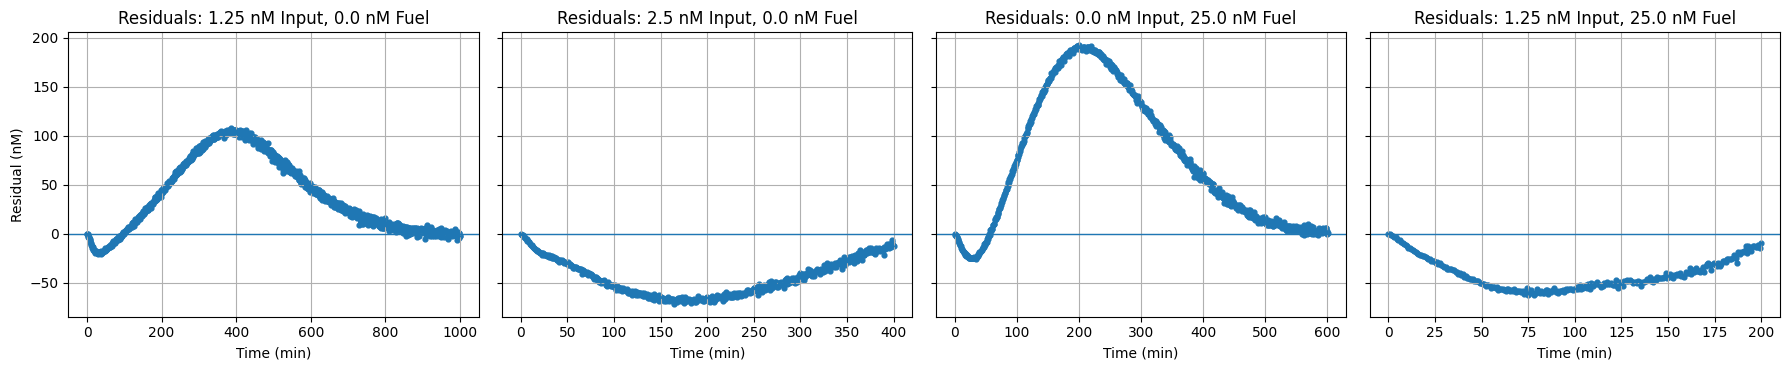

In [36]:
# ============================================================
# 14) PLOT RESIDUALS
# ============================================================

n = len(datasets)
fig, axes = plt.subplots(1, n, figsize=(4.5*n, 3.8), sharey=True)

if n == 1:
    axes = [axes]

for ax, d in zip(axes, datasets):

    x_fit = simulate_ROL(
        t_exp=d["t_exp"],
        IN_conc=d["IN_conc"],
        Fuel_conc=d["Fuel_conc"],
        DRL_0=d["DRL_0"],
        params=best_fit_params
    )

    res = x_fit - d["x_exp"]

    ax.axhline(0, linewidth=1)
    ax.plot(d["t_exp"], res, linewidth=1.5)
    ax.scatter(d["t_exp"], res, s=12)

    ax.set_title(f'Residuals: {d["name"]}')
    ax.set_xlabel('Time (min)')
    ax.grid(True)

axes[0].set_ylabel('Residual (nM)')

plt.tight_layout()
plt.show()


In [37]:
# Number of scan points for cost landscapes
N_SCAN = 50

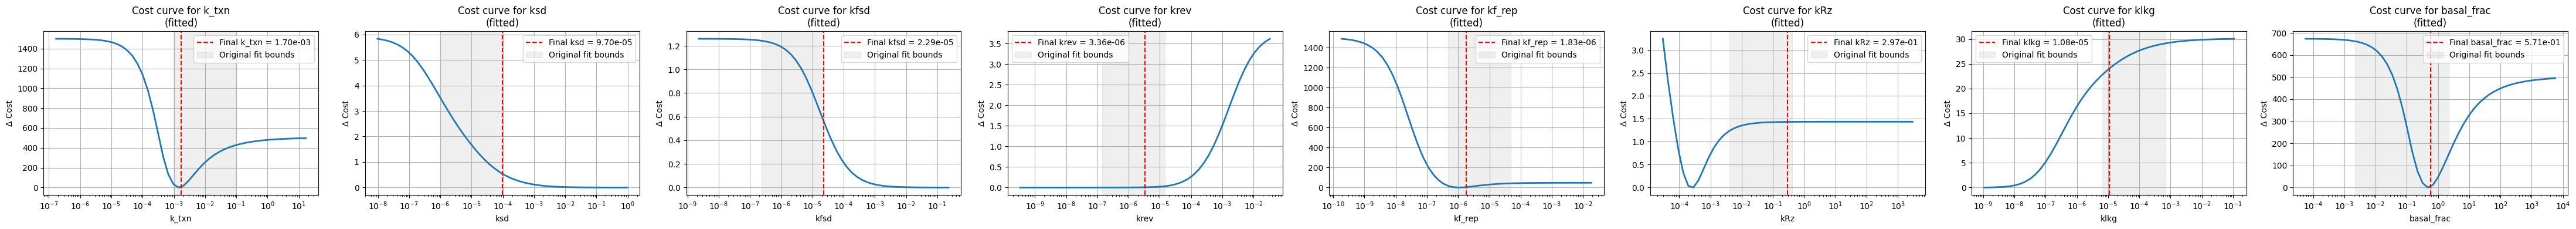

In [38]:
# ============================================================
# 15) AUTOMATIC COST LANDSCAPES FOR CHOSEN SCAN_PARAMS
# ============================================================

SCAN_PARAMS = FIT_PARAMS.copy()

SCAN_HALF_WIDTH_LOG10 = 4.0   # scan +/- this many log10 units around final value

n_params = len(SCAN_PARAMS)
fig, axes = plt.subplots(1, n_params, figsize=(5.5 * n_params, 4))

if n_params == 1:
    axes = [axes]

for ax, p in zip(axes, SCAN_PARAMS):

    center_val = best_fit_params[p]
    center_log10 = np.log10(center_val)

    param_vals = np.logspace(
        center_log10 - SCAN_HALF_WIDTH_LOG10,
        center_log10 + SCAN_HALF_WIDTH_LOG10,
        N_SCAN
    )

    cost_vals = []

    for p_test in param_vals:

        params = best_fit_params.copy()
        params[p] = p_test

        res_all = []

        for d in datasets:

            x_model = simulate_ROL(
                t_exp=d["t_exp"],
                IN_conc=d["IN_conc"],
                Fuel_conc=d["Fuel_conc"],
                DRL_0=d["DRL_0"],
                params=params
            )

            scale = np.max(d["x_exp"]) if np.max(d["x_exp"]) > 0 else 1.0
            res = (x_model - d["x_exp"]) / scale
            res_all.append(res)

        res_all = np.concatenate(res_all)
        cost_vals.append(np.sum(res_all**2))

    cost_vals = np.array(cost_vals)
    delta_cost = cost_vals - np.min(cost_vals)

    ax.semilogx(param_vals, delta_cost, linewidth=2)

    ax.axvline(
        best_fit_params[p],
        linestyle='--',
        linewidth=1.5,
        color='red',
        label=f'Final {p} = {best_fit_params[p]:.2e}'
    )

    if p in FIT_BOUNDS:
        lower_bound, upper_bound = FIT_BOUNDS[p]
        ax.axvspan(
            lower_bound,
            upper_bound,
            alpha=0.12,
            color='gray',
            label='Original fit bounds'
        )

    if p in FIT_PARAMS:
        title_suffix = "(fitted)"
    else:
        title_suffix = "(fixed)"

    ax.set_xlabel(p)
    ax.set_ylabel("Δ Cost")
    ax.set_title(f"Cost curve for {p}\n{title_suffix}")
    ax.grid(True)
    ax.legend()

plt.tight_layout()
plt.show()
